This notebook refits the selected forecasting models using all available data
through April 4, 2026, and generates terminal forecasts for April 5 through
May 30, 2026.

In [78]:
import pandas as pd
import numpy as np
from pathlib import Path
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.dates as mdates

DATA_PATH = Path(
    "../data/processed/daily_terminal_volume.csv"
)

df_final = pd.read_csv(
    DATA_PATH,
    parse_dates=["Date"]
)

df_final = (
    df_final
    .sort_values(["location", "Date"])
    .reset_index(drop=True)
)

FORECAST_FIGURE_DIRECTORY = Path(
    "../outputs/figures/forecast"
)

FORECAST_FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

In [23]:
#checking the holiday flag exist and is numeric
if "holiday_flag" not in df_final.columns:
    df_final["holiday_flag"] = (
        df_final["is_holiday"]
        .astype(str)
        .str.lower()
        .map({
            "true": 1,
            "false": 0
        })
    )

df_final["holiday_flag"] = (
    df_final["holiday_flag"]
    .astype(int)
)

In [24]:
#Setting the forecast period
FORECAST_START = pd.Timestamp("2026-04-05")
FORECAST_END = pd.Timestamp("2026-05-30")

forecast_dates = pd.date_range(
    FORECAST_START,
    FORECAST_END,
    freq="D"
)

print(f"Forecast start: {FORECAST_START.date()}")
print(f"Forecast end:   {FORECAST_END.date()}")
print(f"Forecast days:  {len(forecast_dates)}")

Forecast start: 2026-04-05
Forecast end:   2026-05-30
Forecast days:  56


In [25]:
#rechecking the loaded history 
data_check = pd.Series({
    "rows": len(df_final),
    "locations": df_final["location"].nunique(),
    "first_date": df_final["Date"].min(),
    "last_date": df_final["Date"].max(),
    "missing_model_volume": (
        df_final["model_volume"].isna().sum()
    ),
    "duplicate_date_location": (
        df_final.duplicated(["Date", "location"]).sum()
    )
})

display(data_check)

rows                                     15360
locations                                    8
first_date                 2021-01-01 00:00:00
last_date                  2026-04-04 00:00:00
missing_model_volume                         0
duplicate_date_location                      0
dtype: object

In [26]:
#creating the future dates for all locations. Also creating the holidays for that period.
import holidays

canadian_holidays = holidays.country_holidays(
    "CA",
    subdiv="AB",
    years=[2026],
    observed=True
)

future_calendar = (
    pd.MultiIndex.from_product(
        [forecast_dates, locations],
        names=["Date", "location"]
    )
    .to_frame(index=False)
)

future_calendar["holiday_flag"] = (
    future_calendar["Date"]
    .dt.date
    .map(
        lambda date: int(date in canadian_holidays)
    )
)

In [27]:
#checking the calendar created
calendar_check = pd.Series({
    "rows": len(future_calendar),
    "locations": future_calendar["location"].nunique(),
    "first_date": future_calendar["Date"].min(),
    "last_date": future_calendar["Date"].max(),
    "forecast_days": future_calendar["Date"].nunique(),
    "holiday_dates": (
        future_calendar.loc[
            future_calendar["holiday_flag"] == 1,
            "Date"
        ].nunique()
    ),
    "duplicate_date_location": (
        future_calendar
        .duplicated(["Date", "location"])
        .sum()
    )
})

display(calendar_check)

rows                                       448
locations                                    8
first_date                 2026-04-05 00:00:00
last_date                  2026-05-30 00:00:00
forecast_days                               56
holiday_dates                                1
duplicate_date_location                      0
dtype: object

In [28]:
#viewing the holidays foud in the forecast period.
forecast_holidays = (
    future_calendar.loc[
        future_calendar["holiday_flag"] == 1,
        ["Date"]
    ]
    .drop_duplicates()
    .sort_values("Date")
)

forecast_holidays["holiday_name"] = (
    forecast_holidays["Date"]
    .dt.date
    .map(canadian_holidays.get)
)

display(forecast_holidays)

,Date,holiday_name
344,2026-05-18,Victoria Day


In [48]:
#Defining the best models for each location
BEST_MODEL_BY_LOCATION = {
    1: "Holiday SARIMA",
    2: "XGBoost",
    3: "Holiday SARIMA",
    4: "Holiday SARIMA",
    5: "Seasonal naïve",
    6: "XGBoost",
    7: "XGBoost",
    8: "XGBoost"
}

SARIMA_LOCATIONS = [1, 3, 4, 5]
XGBOOST_LOCATIONS = [2, 6, 7, 8]

In [49]:
#loading hte SARIMA configurations used 
SARIMA_ORDER = (1, 0, 1)
SARIMA_SEASONAL_ORDER = (0, 1, 1, 7)

#setting the save paths for the models and forecast
MODEL_DIRECTORY = Path("../outputs/models")
FORECAST_DIRECTORY = Path("../outputs/forecasts")


In [50]:
#validating the model assignment
model_plan = pd.DataFrame({
    "location": sorted(BEST_MODEL_BY_LOCATION),
    "selected_model": [
        BEST_MODEL_BY_LOCATION[location]
        for location in sorted(BEST_MODEL_BY_LOCATION)
    ]
})

display(model_plan)

assert set(model_plan["location"]) == set(
    df_final["location"].unique()
)

,location,selected_model
0,1,Holiday SARIMA
1,2,XGBoost
2,3,Holiday SARIMA
3,4,Holiday SARIMA
4,5,Seasonal naïve
5,6,XGBoost
6,7,XGBoost
7,8,XGBoost


In [51]:
#Creating the Holiday flag in historical data
df_final["Date"] = pd.to_datetime(
    df_final["Date"]
)

historical_years = range(
    df_final["Date"].dt.year.min(),
    df_final["Date"].dt.year.max() + 1
)

alberta_holidays = holidays.country_holidays(
    "CA",
    subdiv="AB",
    years=historical_years,
    observed=True
)

df_final["holiday_flag"] = (
    df_final["Date"]
    .dt.date
    .map(lambda date: int(date in alberta_holidays))
)

In [52]:
#Refitting the SARIMA model for the locations 1,3 and 4.

sarima_forecasts = []
sarima_model_results = []

for location in SARIMA_LOCATIONS:
    print(f"Fitting Holiday SARIMA for location {location}")

    location_history = (
        df_final.loc[
            df_final["location"] == location,
            ["Date", "model_volume", "holiday_flag"]
        ]
        .set_index("Date")
        .sort_index()
        .asfreq("D")
    )

    future_exog = (
        future_calendar.loc[
            future_calendar["location"] == location,
            ["Date", "holiday_flag"]
        ]
        .set_index("Date")
        .sort_index()
        .reindex(forecast_dates)
    )

    sarima_model = SARIMAX(
        endog=location_history["model_volume"],
        exog=location_history[["holiday_flag"]],
        order=SARIMA_ORDER,
        seasonal_order=SARIMA_SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    sarima_result = sarima_model.fit(
        disp=False
    )

    predicted_volume = (
        sarima_result
        .get_forecast(
            steps=len(forecast_dates),
            exog=future_exog[["holiday_flag"]]
        )
        .predicted_mean
        .clip(lower=0)
    )

    location_forecast = pd.DataFrame({
        "Date": forecast_dates,
        "location": location,
        "forecast_volume": predicted_volume.to_numpy(),
        "selected_model": "Holiday SARIMA"
    })

    sarima_forecasts.append(location_forecast)

    model_path = (
        MODEL_DIRECTORY
        / f"holiday_sarima_location_{location}.pkl"
    )

    sarima_result.save(str(model_path))

    sarima_model_results.append({
        "location": location,
        "converged": sarima_result.mle_retvals.get(
            "converged",
            None
        ),
        "AIC": sarima_result.aic,
        "model_path": str(model_path)
    })

Fitting Holiday SARIMA for location 1
Fitting Holiday SARIMA for location 3
Fitting Holiday SARIMA for location 4
Fitting Holiday SARIMA for location 5


In [53]:
#combining the forecasts 
sarima_final_forecasts = pd.concat(
    sarima_forecasts,
    ignore_index=True
)

sarima_fit_summary = pd.DataFrame(
    sarima_model_results
)

display(sarima_fit_summary)
display(sarima_final_forecasts.head())

,location,converged,AIC,model_path
0,1,True,28647.782300,..\outputs\models\holiday_sarima_location_1.pkl
1,3,True,29134.901771,..\outputs\models\holiday_sarima_location_3.pkl
2,4,True,23285.317723,..\outputs\models\holiday_sarima_location_4.pkl
3,5,True,16042.853374,..\outputs\models\holiday_sarima_location_5.pkl


,Date,location,forecast_volume,selected_model
0,2026-04-05,1,0.000000,Holiday SARIMA
1,2026-04-06,1,2457.349239,Holiday SARIMA
2,2026-04-07,1,2643.756403,Holiday SARIMA
3,2026-04-08,1,2289.729332,Holiday SARIMA
4,2026-04-09,1,2113.381599,Holiday SARIMA


In [54]:
#Validating the output
sarima_forecast_check = (
    sarima_final_forecasts
    .groupby("location")
    .agg(
        forecast_days=("Date", "nunique"),
        minimum_forecast=("forecast_volume", "min"),
        average_forecast=("forecast_volume", "mean"),
        maximum_forecast=("forecast_volume", "max")
    )
)

display(sarima_forecast_check.round(2))

,forecast_days,minimum_forecast,average_forecast,maximum_forecast
location,,,,
1,56,0.00,1637.75,2694.69
3,56,0.00,1952.49,3090.50
4,56,6.86,371.50,567.25
5,56,0.00,38.79,59.94


In [55]:
#Creating the weekday summary
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

sarima_weekday_summary = (
    sarima_final_forecasts.copy()
)

sarima_weekday_summary["weekday"] = (
    sarima_weekday_summary["Date"].dt.day_name()
)

sarima_weekday_summary = (
    sarima_weekday_summary
    .groupby(
        ["location", "weekday"],
        as_index=False
    )
    .agg(
        average_forecast=("forecast_volume", "mean")
    )
)

sarima_weekday_summary["weekday"] = pd.Categorical(
    sarima_weekday_summary["weekday"],
    categories=weekday_order,
    ordered=True
)

sarima_weekday_summary = (
    sarima_weekday_summary
    .sort_values(["location", "weekday"])
)

display(sarima_weekday_summary.round(2))

,location,weekday,average_forecast
1,1,Monday,2298.15
5,1,Tuesday,2677.84
6,1,Wednesday,2322.03
4,1,Thursday,2143.99
0,1,Friday,2022.20
2,1,Saturday,0.03
3,1,Sunday,0.00
8,3,Monday,2451.52
12,3,Tuesday,3064.45
13,3,Wednesday,3038.06


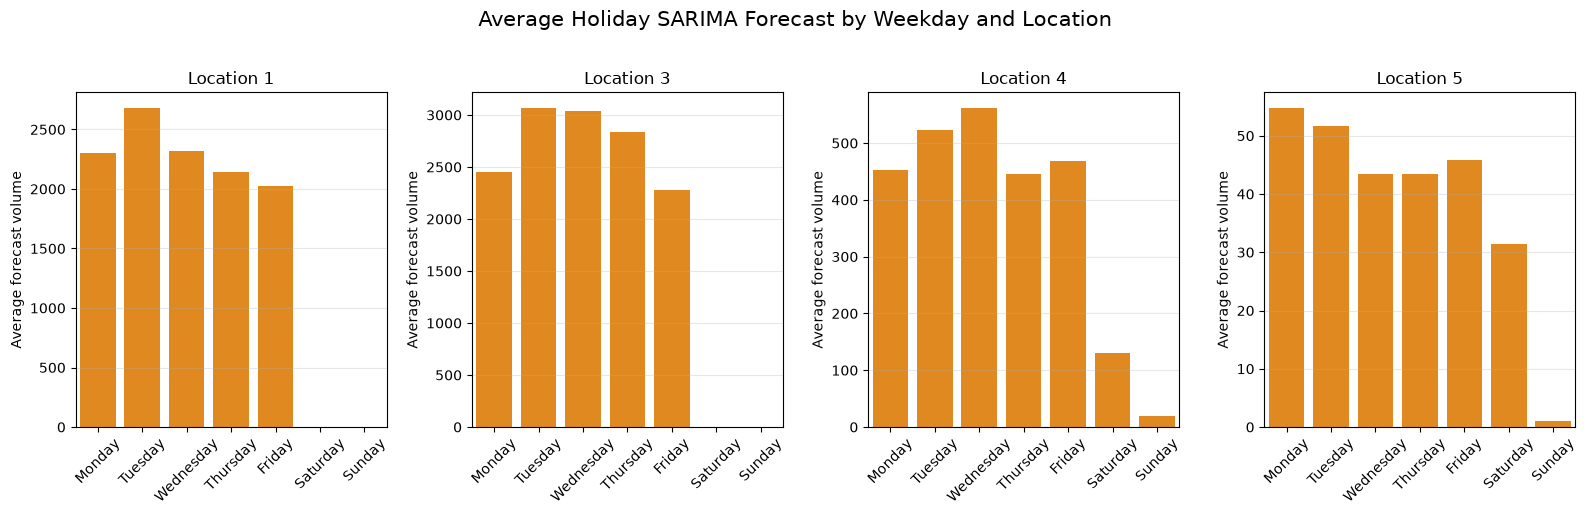

Saved: F:\Forecasting\Sukh-Forecast\outputs\figures\forecast\sarima_average_forecast_by_weekday.png


In [56]:
#plotting chart
locations = sorted(
    sarima_weekday_summary["location"].unique()
)

fig, axes = plt.subplots(
    1,
    len(locations),
    figsize=(16, 5),
    sharey=False
)

if len(locations) == 1:
    axes = [axes]

for ax, location in zip(axes, locations):
    location_data = sarima_weekday_summary[
        sarima_weekday_summary["location"] == location
    ]

    sns.barplot(
        data=location_data,
        x="weekday",
        y="average_forecast",
        order=weekday_order,
        color="darkorange",
        ax=ax
    )

    ax.set_title(f"Location {location}")
    ax.set_xlabel("")
    ax.set_ylabel("Average forecast volume")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(
    "Average Holiday SARIMA Forecast by Weekday and Location",
    fontsize=15,
    y=1.02
)

plt.tight_layout()

figure_path = (
    FORECAST_FIGURE_DIRECTORY
    / "sarima_average_forecast_by_weekday.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Saved: {figure_path.resolve()}")

In [58]:
#Creating xgboost fetures
def create_xgboost_features(data):
    features = data.copy()

    features["Date"] = pd.to_datetime(features["Date"])

    features = features.sort_values(
        ["location", "Date"]
    ).reset_index(drop=True)

    features["day_of_week"] = (
        features["Date"].dt.dayofweek
    )

    features["month"] = features["Date"].dt.month

    features["week_of_year"] = (
        features["Date"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

    features["day_of_year"] = (
        features["Date"].dt.dayofyear
    )

    features["is_weekend"] = (
        features["day_of_week"] >= 5
    ).astype(int)

    features["day_of_week_sin"] = np.sin(
        2 * np.pi * features["day_of_week"] / 7
    )

    features["day_of_week_cos"] = np.cos(
        2 * np.pi * features["day_of_week"] / 7
    )

    features["day_of_year_sin"] = np.sin(
        2 * np.pi * features["day_of_year"] / 365.25
    )

    features["day_of_year_cos"] = np.cos(
        2 * np.pi * features["day_of_year"] / 365.25
    )

    volume_group = features.groupby(
        "location"
    )["model_volume"]

    for lag in [1, 7, 14, 21, 28, 56, 364, 365]:
        features[f"lag_{lag}"] = (
            volume_group.shift(lag)
        )

    for window in [7, 28, 56]:
        features[f"rolling_mean_{window}"] = (
            features.groupby("location")[
                "model_volume"
            ]
            .transform(
                lambda series: (
                    series.shift(1)
                    .rolling(window)
                    .mean()
                )
            )
        )

    features["rolling_median_28"] = (
        features.groupby("location")[
            "model_volume"
        ]
        .transform(
            lambda series: (
                series.shift(1)
                .rolling(28)
                .median()
            )
        )
    )

    features["rolling_std_28"] = (
        features.groupby("location")[
            "model_volume"
        ]
        .transform(
            lambda series: (
                series.shift(1)
                .rolling(28)
                .std()
            )
        )
    )

    features["same_weekday_mean_4"] = (
        features.groupby(
            ["location", "day_of_week"]
        )["model_volume"]
        .transform(
            lambda series: (
                series.shift(1)
                .rolling(4)
                .mean()
            )
        )
    )

    features["same_weekday_median_4"] = (
        features.groupby(
            ["location", "day_of_week"]
        )["model_volume"]
        .transform(
            lambda series: (
                series.shift(1)
                .rolling(4)
                .median()
            )
        )
    )

    features["_operating_value"] = np.where(
        features["model_volume"].isna(),
        np.nan,
        (features["model_volume"] > 0).astype(float)
    )

    features["same_weekday_operation_rate_8"] = (
        features.groupby(
            ["location", "day_of_week"]
        )["_operating_value"]
        .transform(
            lambda series: (
                series.shift(1)
                .rolling(8)
                .mean()
            )
        )
    )

    features["mean_7_vs_28"] = (
        features["rolling_mean_7"]
        / features["rolling_mean_28"].replace(0, np.nan)
    )

    features["mean_28_vs_56"] = (
        features["rolling_mean_28"]
        / features["rolling_mean_56"].replace(0, np.nan)
    )

    return features.drop(
        columns=["_operating_value"]
    )

In [59]:
FEATURE_COLUMNS = [
    "location",
    "day_of_week",
    "month",
    "week_of_year",
    "is_weekend",
    "holiday_flag",
    "day_of_week_sin",
    "day_of_week_cos",
    "day_of_year_sin",
    "day_of_year_cos",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_21",
    "lag_28",
    "lag_56",
    "lag_364",
    "lag_365",
    "rolling_mean_7",
    "rolling_mean_28",
    "rolling_mean_56",
    "rolling_median_28",
    "rolling_std_28",
    "same_weekday_mean_4",
    "same_weekday_median_4",
    "same_weekday_operation_rate_8",
    "mean_7_vs_28",
    "mean_28_vs_56"
]

In [60]:
#Creating the final training dataset
final_xgb_features = create_xgboost_features(
    df_final
)

final_xgb_training = (
    final_xgb_features
    .dropna(
        subset=FEATURE_COLUMNS + ["model_volume"]
    )
    .copy()
)

In [61]:
#encoding the categorial features
X_final = pd.get_dummies(
    final_xgb_training[FEATURE_COLUMNS],
    columns=["location", "day_of_week"],
    dtype=float
)

y_final = final_xgb_training["model_volume"]

ENCODED_FEATURE_COLUMNS = X_final.columns.tolist()

print("Training rows:", len(X_final))
print("Encoded features:", len(ENCODED_FEATURE_COLUMNS))

Training rows: 12440
Encoded features: 41


In [62]:
from xgboost import XGBRegressor
import json

FINAL_XGB_PARAMS = {
    "objective": "reg:squarederror",
    "eval_metric": "mae",
    "learning_rate": 0.03,
    "max_depth": 6,
    "min_child_weight": 3,
    "subsample": 0.80,
    "colsample_bytree": 0.70,
    "reg_alpha": 0.10,
    "reg_lambda": 2.0,
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1
}

In [63]:
#using final 56 historical days to figure out number of trees needed.
internal_validation_start = (
    df_final["Date"].max()
    - pd.Timedelta(days=55)
)

inner_train_mask = (
    final_xgb_training["Date"]
    < internal_validation_start
)

inner_validation_mask = (
    final_xgb_training["Date"]
    >= internal_validation_start
)

print(
    "Internal validation starts:",
    internal_validation_start.date()
)

print(
    "Training rows:",
    inner_train_mask.sum()
)

print(
    "Validation rows:",
    inner_validation_mask.sum()
)

Internal validation starts: 2026-02-08
Training rows: 11992
Validation rows: 448


In [64]:
#Determining the number of trees
xgb_early_stop_model = XGBRegressor(
    **FINAL_XGB_PARAMS,
    n_estimators=1500,
    early_stopping_rounds=75
)

xgb_early_stop_model.fit(
    X_final.loc[inner_train_mask],
    y_final.loc[inner_train_mask],
    eval_set=[(
        X_final.loc[inner_validation_mask],
        y_final.loc[inner_validation_mask]
    )],
    verbose=False
)

FINAL_NUMBER_OF_TREES = (
    xgb_early_stop_model.best_iteration + 1
)

print(
    "Selected number of trees:",
    FINAL_NUMBER_OF_TREES
)

Selected number of trees: 910


In [65]:
#Refitting the model on all available data
xgb_final_model = XGBRegressor(
    **FINAL_XGB_PARAMS,
    n_estimators=FINAL_NUMBER_OF_TREES
)

xgb_final_model.fit(
    X_final,
    y_final,
    verbose=False
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'mae'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [66]:
#save the fitted model
xgb_model_path = (
    MODEL_DIRECTORY / "xgboost_global.json"
)

xgb_final_model.save_model(
    str(xgb_model_path)
)

print(f"Saved: {xgb_model_path.resolve()}")

Saved: F:\Forecasting\Sukh-Forecast\outputs\models\xgboost_global.json


In [67]:
#saving the configuration and feature columns
xgb_metadata = {
    "training_end_date": str(
        df_final["Date"].max().date()
    ),
    "forecast_start_date": str(
        FORECAST_START.date()
    ),
    "forecast_end_date": str(
        FORECAST_END.date()
    ),
    "n_estimators": int(
        FINAL_NUMBER_OF_TREES
    ),
    "parameters": FINAL_XGB_PARAMS,
    "feature_columns": FEATURE_COLUMNS,
    "encoded_feature_columns": (
        ENCODED_FEATURE_COLUMNS
    ),
    "forecast_locations": XGBOOST_LOCATIONS
}

metadata_path = (
    MODEL_DIRECTORY / "xgboost_metadata.json"
)

with open(metadata_path, "w") as file:
    json.dump(
        xgb_metadata,
        file,
        indent=4
    )

print(f"Saved: {metadata_path.resolve()}")

Saved: F:\Forecasting\Sukh-Forecast\outputs\models\xgboost_metadata.json


In [69]:
#create the recursive hirtory for forecasted locations
recursive_history = (
    df_final.loc[
        df_final["location"].isin(
            XGBOOST_LOCATIONS
        ),
        [
            "Date",
            "location",
            "model_volume",
            "holiday_flag"
        ]
    ]
    .copy()
    .sort_values(["location", "Date"])
)

xgb_forecast_rows = []

In [71]:
#forecasting the future dates recursively
for forecast_date in forecast_dates:
    current_calendar = (
        future_calendar.loc[
            (future_calendar["Date"] == forecast_date)
            & (
                future_calendar["location"].isin(
                    XGBOOST_LOCATIONS
                )
            ),
            ["Date", "location", "holiday_flag"]
        ]
        .copy()
        .sort_values("location")
    )

    # Target is unknown for the future date
    current_calendar["model_volume"] = np.nan

    recursive_history = pd.concat(
        [recursive_history, current_calendar],
        ignore_index=True
    )

    recursive_features = create_xgboost_features(
        recursive_history
    )

    current_features = (
        recursive_features.loc[
            recursive_features["Date"]
            == forecast_date
        ]
        .sort_values("location")
        .copy()
    )

    missing_features = (
        current_features[FEATURE_COLUMNS]
        .isna()
        .sum()
    )

    missing_feature_details = (
    missing_features[
        missing_features > 0
    ]
    .to_dict()
)

    if missing_feature_details:
        raise ValueError(
            f"Missing features on "
            f"{forecast_date.date()}: "
            f"{missing_feature_details}"
        )

    X_future = pd.get_dummies(
        current_features[FEATURE_COLUMNS],
        columns=["location", "day_of_week"],
        dtype=float
    )

    X_future = X_future.reindex(
        columns=ENCODED_FEATURE_COLUMNS,
        fill_value=0
    )

    predictions = np.maximum(
        xgb_final_model.predict(X_future),
        0
    )

    daily_forecast = current_features[
        ["Date", "location"]
    ].copy()

    daily_forecast["forecast_volume"] = predictions
    daily_forecast["selected_model"] = "XGBoost"

    xgb_forecast_rows.append(daily_forecast)

    # Add predictions back into history for future lag features
    prediction_map = dict(
        zip(
            daily_forecast["location"],
            daily_forecast["forecast_volume"]
        )
    )

    current_date_mask = (
        recursive_history["Date"]
        == forecast_date
    )

    recursive_history.loc[
        current_date_mask,
        "model_volume"
    ] = recursive_history.loc[
        current_date_mask,
        "location"
    ].map(prediction_map)

In [72]:
#combining the forecast
xgb_final_forecasts = pd.concat(
    xgb_forecast_rows,
    ignore_index=True
)

display(xgb_final_forecasts.head(12))

,Date,location,forecast_volume,selected_model
0,2026-04-05,2,15.823428,XGBoost
1,2026-04-05,6,49.112087,XGBoost
2,2026-04-05,7,280.164612,XGBoost
3,2026-04-05,8,318.328644,XGBoost
4,2026-04-06,2,480.818817,XGBoost
5,2026-04-06,6,5123.018066,XGBoost
6,2026-04-06,7,4861.388184,XGBoost
7,2026-04-06,8,7802.249023,XGBoost
8,2026-04-07,2,482.939148,XGBoost
9,2026-04-07,6,6030.658203,XGBoost


In [73]:
#validating the forecast 
xgb_forecast_check = (
    xgb_final_forecasts
    .groupby("location")
    .agg(
        forecast_days=("Date", "nunique"),
        minimum_forecast=("forecast_volume", "min"),
        average_forecast=("forecast_volume", "mean"),
        maximum_forecast=("forecast_volume", "max")
    )
)

display(xgb_forecast_check.round(2))

,forecast_days,minimum_forecast,average_forecast,maximum_forecast
location,,,,
2,56,10.930000,312.589996,515.650024
6,56,39.290001,3989.709961,6255.839844
7,56,219.350006,3811.649902,6533.979980
8,56,307.769989,5444.810059,8289.650391


In [74]:
#combining the SARIMA and XGboost forecasts
final_terminal_forecast = pd.concat(
    [
        sarima_final_forecasts,
        xgb_final_forecasts
    ],
    ignore_index=True
)

In [75]:
#merging the forecast with rest of the columns
final_terminal_forecast = (
    final_terminal_forecast
    .merge(
        future_calendar[
            ["Date", "location", "holiday_flag"]
        ],
        on=["Date", "location"],
        how="left"
    )
)

final_terminal_forecast["weekday"] = (
    final_terminal_forecast["Date"]
    .dt.day_name()
)

final_terminal_forecast["forecast_volume"] = (
    final_terminal_forecast["forecast_volume"]
    .clip(lower=0)
    .round()
    .astype(int)
)

final_terminal_forecast = (
    final_terminal_forecast[
        [
            "Date",
            "location",
            "weekday",
            "holiday_flag",
            "forecast_volume",
            "selected_model"
        ]
    ]
    .sort_values(["location", "Date"])
    .reset_index(drop=True)
)

In [76]:
#final validation
final_forecast_check = pd.Series({
    "rows": len(final_terminal_forecast),
    "locations": (
        final_terminal_forecast["location"].nunique()
    ),
    "forecast_days": (
        final_terminal_forecast["Date"].nunique()
    ),
    "first_date": (
        final_terminal_forecast["Date"].min()
    ),
    "last_date": (
        final_terminal_forecast["Date"].max()
    ),
    "missing_forecasts": (
        final_terminal_forecast[
            "forecast_volume"
        ].isna().sum()
    ),
    "negative_forecasts": (
        final_terminal_forecast[
            "forecast_volume"
        ].lt(0).sum()
    ),
    "duplicate_date_location": (
        final_terminal_forecast
        .duplicated(["Date", "location"])
        .sum()
    )
})

display(final_forecast_check)

rows                                       448
locations                                    8
forecast_days                               56
first_date                 2026-04-05 00:00:00
last_date                  2026-05-30 00:00:00
missing_forecasts                            0
negative_forecasts                           0
duplicate_date_location                      0
dtype: object

In [77]:
#save the final forecast
final_forecast_path = (
    FORECAST_DIRECTORY
    / "final_terminal_forecast.csv"
)

final_terminal_forecast.to_csv(
    final_forecast_path,
    index=False
)

print(
    f"Saved final forecast: "
    f"{final_forecast_path.resolve()}"
)

Saved final forecast: F:\Forecasting\Sukh-Forecast\outputs\forecasts\final_terminal_forecast.csv


In [79]:
#organizing the data for plotting
HISTORY_DAYS = 14

history_start = (
    FORECAST_START
    - pd.Timedelta(days=HISTORY_DAYS)
)

recent_history = (
    df_final.loc[
        (df_final["Date"] >= history_start)
        & (df_final["Date"] < FORECAST_START),
        ["Date", "location", "model_volume"]
    ]
    .copy()
    .sort_values(["location", "Date"])
)

plot_forecast = final_terminal_forecast.copy()

plot_forecast["Date"] = pd.to_datetime(
    plot_forecast["Date"]
)

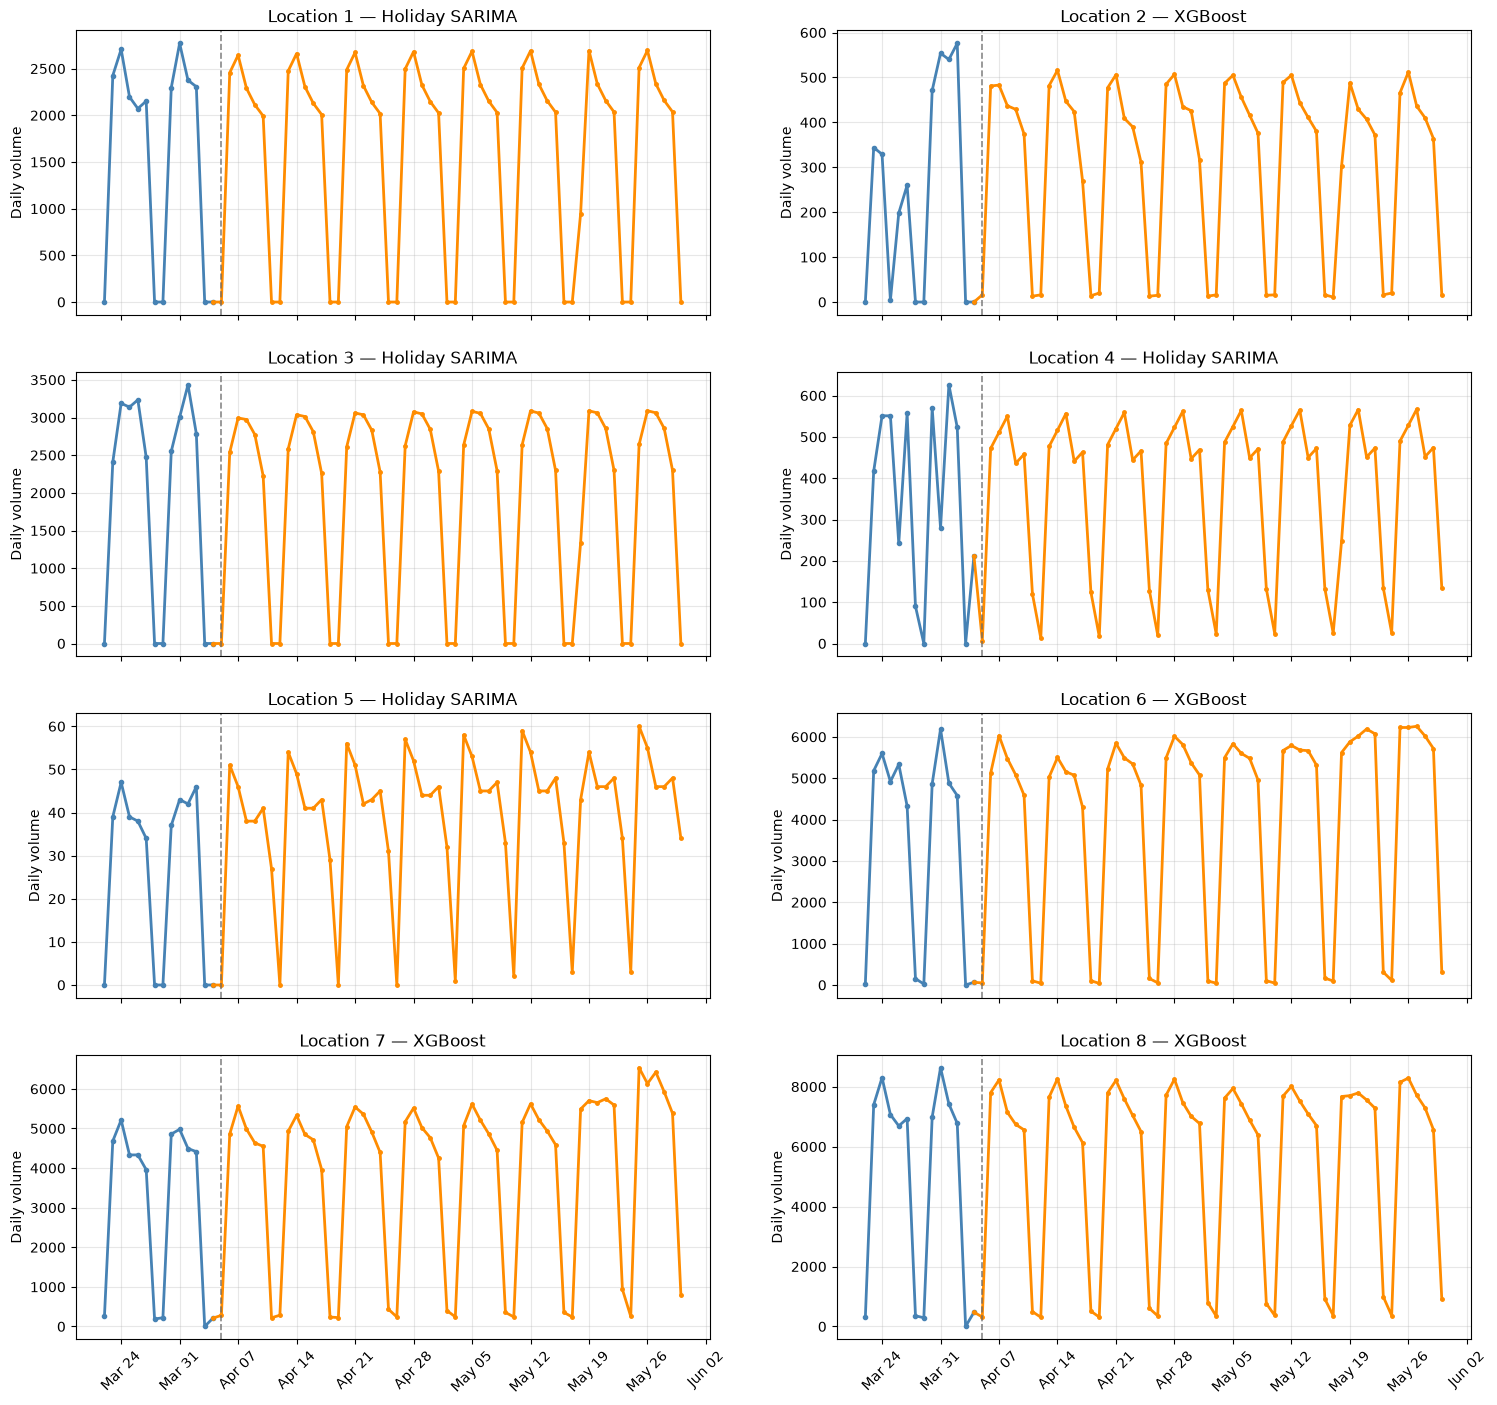

In [80]:
#creating the plot
fig, axes = plt.subplots(
    4,
    2,
    figsize=(18, 17),
    sharex=True
)

axes = axes.flatten()

for ax, location in zip(
    axes,
    sorted(plot_forecast["location"].unique())
):
    location_history = (
        recent_history.loc[
            recent_history["location"] == location
        ]
        .sort_values("Date")
    )

    location_forecast = (
        plot_forecast.loc[
            plot_forecast["location"] == location
        ]
        .sort_values("Date")
    )

    selected_model = (
        location_forecast["selected_model"].iloc[0]
    )

    # Historical line
    ax.plot(
        location_history["Date"],
        location_history["model_volume"],
        color="steelblue",
        linewidth=2,
        marker="o",
        markersize=3,
        label="Historical"
    )

    # Add the final actual point to the forecast line
    forecast_connection = pd.concat(
        [
            pd.DataFrame({
                "Date": [
                    location_history["Date"].iloc[-1]
                ],
                "forecast_volume": [
                    location_history[
                        "model_volume"
                    ].iloc[-1]
                ]
            }),
            location_forecast[
                ["Date", "forecast_volume"]
            ]
        ],
        ignore_index=True
    )

    # Forecast line
    ax.plot(
        forecast_connection["Date"],
        forecast_connection["forecast_volume"],
        color="darkorange",
        linewidth=2,
        marker="o",
        markersize=2.5,
        label="Forecast"
    )

    # Forecast-period boundary
    ax.axvline(
        FORECAST_START,
        color="dimgray",
        linestyle="--",
        linewidth=1.2,
        alpha=0.8
    )

    ax.set_title(
        f"Location {location} — {selected_model}"
    )

    ax.set_ylabel("Daily volume")
    ax.grid(alpha=0.3)

    ax.xaxis.set_major_locator(
        mdates.WeekdayLocator(interval=1)
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%b %d")
    )

    ax.tick_params(
        axis="x",
        rotation=45
    )

In [81]:
#adding the legend, subtitles
handles, labels = (
    axes[0].get_legend_handles_labels()
)

fig.suptitle(
    "Daily Terminal Volume: Historical and Final Forecast",
    fontsize=16,
    y=0.995
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.968),
    ncol=2,
    frameon=False
)

plt.tight_layout(
    rect=[0, 0, 1, 0.93]
)

forecast_figure_path = (
    FORECAST_FIGURE_DIRECTORY
    / "final_daily_forecast_by_location.png"
)

fig.savefig(
    forecast_figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(
    f"Saved: {forecast_figure_path.resolve()}"
)

<Figure size 640x480 with 0 Axes>

Saved: F:\Forecasting\Sukh-Forecast\outputs\figures\forecast\final_daily_forecast_by_location.png
